# Exploratory Data Analysis (EDA)

## Employee Dataset

### Objective

The objective of this EDA is to understand the employee dataset,
identify important patterns, examine relationships between variables,
and generate meaningful business insights.

The analysis focuses on:

- Employee demographics
- Departments and job roles
- Salary and experience
- Performance and training
- Job satisfaction and work-life balance
- Promotion patterns
- Employee attrition
- Correlation between numerical variables

The dataset used for this analysis has already been cleaned.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [5]:
df = pd.read_csv("cleaned_internship.csv")

## 1. Dataset Overview

We begin by examining the size, structure, and basic characteristics
of the cleaned dataset.

In [6]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 5000
Number of Columns: 21


In [7]:
df.head()

,Employee_ID,Age,Department,Job_Role,Job_Level,Years_At_Company,Years_In_Current_Role,Years_Since_Last_Promotion,Expected_Promotion_Years,Promotion_Gap_Years,...,Performance_Rating,Salary,Training_Hours,Job_Satisfaction,Work_Life_Balance,Manager_Tenure_Years,Remote_Work,Overtime,Promotion_Status,Attrition
0,PANW00001,37,Sales,Sales Manager,3,5.7,3.0,2.8,3.0,-0.2,...,2.6,128300,69.0,3.3,3.0,0.8,No,No,Promoted,No
1,PANW00002,28,Product,Product Designer,3,5.5,2.2,1.5,3.0,-1.5,...,2.4,125600,12.0,3.9,4.0,5.4,No,Yes,Promoted,No
2,PANW00003,27,IT,IT Manager,2,4.5,3.9,4.3,2.5,1.8,...,3.3,100400,41.0,3.4,3.6,3.6,No,No,Not Promoted,No
3,PANW00004,27,Finance,Accountant,4,2.4,1.9,1.4,3.5,-2.1,...,4.1,131500,41.0,5.0,3.6,0.9,No,No,Not Promoted,No
4,PANW00005,35,Engineering,Data Engineer,3,2.8,1.4,1.2,3.0,-1.8,...,2.4,132600,33.0,3.3,2.8,4.5,Yes,No,Not Promoted,No


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_ID                 5000 non-null   str    
 1   Age                         5000 non-null   int64  
 2   Department                  5000 non-null   str    
 3   Job_Role                    5000 non-null   str    
 4   Job_Level                   5000 non-null   int64  
 5   Years_At_Company            5000 non-null   float64
 6   Years_In_Current_Role       5000 non-null   float64
 7   Years_Since_Last_Promotion  5000 non-null   float64
 8   Expected_Promotion_Years    5000 non-null   float64
 9   Promotion_Gap_Years         5000 non-null   float64
 10  Last_Promotion_Year         5000 non-null   int64  
 11  Performance_Rating          5000 non-null   float64
 12  Salary                      5000 non-null   int64  
 13  Training_Hours              5000 non-null   

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,32.14760,6.635286,21.0,27.0,32.0,37.0,56.0
Job_Level,5000.0,2.72100,1.125616,1.0,2.0,3.0,3.0,5.0
Years_At_Company,5000.0,3.91316,2.645021,0.2,2.0,3.3,5.2,18.0
Years_In_Current_Role,5000.0,2.04366,0.955641,0.1,1.4,2.0,2.7,5.5
Years_Since_Last_Promotion,5000.0,1.82402,0.908058,0.1,1.2,1.8,2.4,6.1
Expected_Promotion_Years,5000.0,2.83010,0.611751,1.8,2.5,3.0,3.0,4.0
Promotion_Gap_Years,5000.0,-1.00608,0.931865,-3.8,-1.6,-1.0,-0.4,2.6
Last_Promotion_Year,5000.0,2024.17620,0.957777,2020.0,2024.0,2024.0,2025.0,2026.0
Performance_Rating,5000.0,3.50264,0.731730,1.0,3.0,3.5,4.0,5.0
Salary,5000.0,117270.56000,26030.830684,51200.0,98100.0,115550.0,135100.0,218100.0


In [10]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()

categorical_cols = [
    col for col in df.select_dtypes(include="str").columns
    if col != "Employee_ID"
]

print("Numerical Columns:")
print(numeric_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['Age', 'Job_Level', 'Years_At_Company', 'Years_In_Current_Role', 'Years_Since_Last_Promotion', 'Expected_Promotion_Years', 'Promotion_Gap_Years', 'Last_Promotion_Year', 'Performance_Rating', 'Salary', 'Training_Hours', 'Job_Satisfaction', 'Work_Life_Balance', 'Manager_Tenure_Years']

Categorical Columns:
['Department', 'Job_Role', 'Remote_Work', 'Overtime', 'Promotion_Status', 'Attrition']


## 2. Categorical Variable Summary

We examine the frequency and proportion of categories in the
categorical variables.

In [11]:
for col in categorical_cols:
    print(f"\n{'='*50}")
    print(col)
    print(f"{'='*50}")
    summary = pd.DataFrame({
        "Count": df[col].value_counts(),
        "Percentage": df[col].value_counts(normalize=True).mul(100).round(2)
    })
    print(summary)


Department
                  Count  Percentage
Department                         
Engineering        1428       28.56
Sales               808       16.16
Product             578       11.56
Customer Success    516       10.32
IT                  474        9.48
Marketing           451        9.02
Finance             414        8.28
HR                  331        6.62

Job_Role
                             Count  Percentage
Job_Role                                      
Software Engineer              367        7.34
Senior Software Engineer       361        7.22
DevOps Engineer                353        7.06
Data Engineer                  347        6.94
Account Executive              274        5.48
Sales Manager                  270        5.40
Sales Representative           264        5.28
Product Analyst                203        4.06
Product Designer               191        3.82
Support Engineer               184        3.68
Product Manager                184        3.68
Custome

## 3. Numerical Variable Distribution

Histograms are used to understand the distribution, concentration,
and spread of numerical variables.

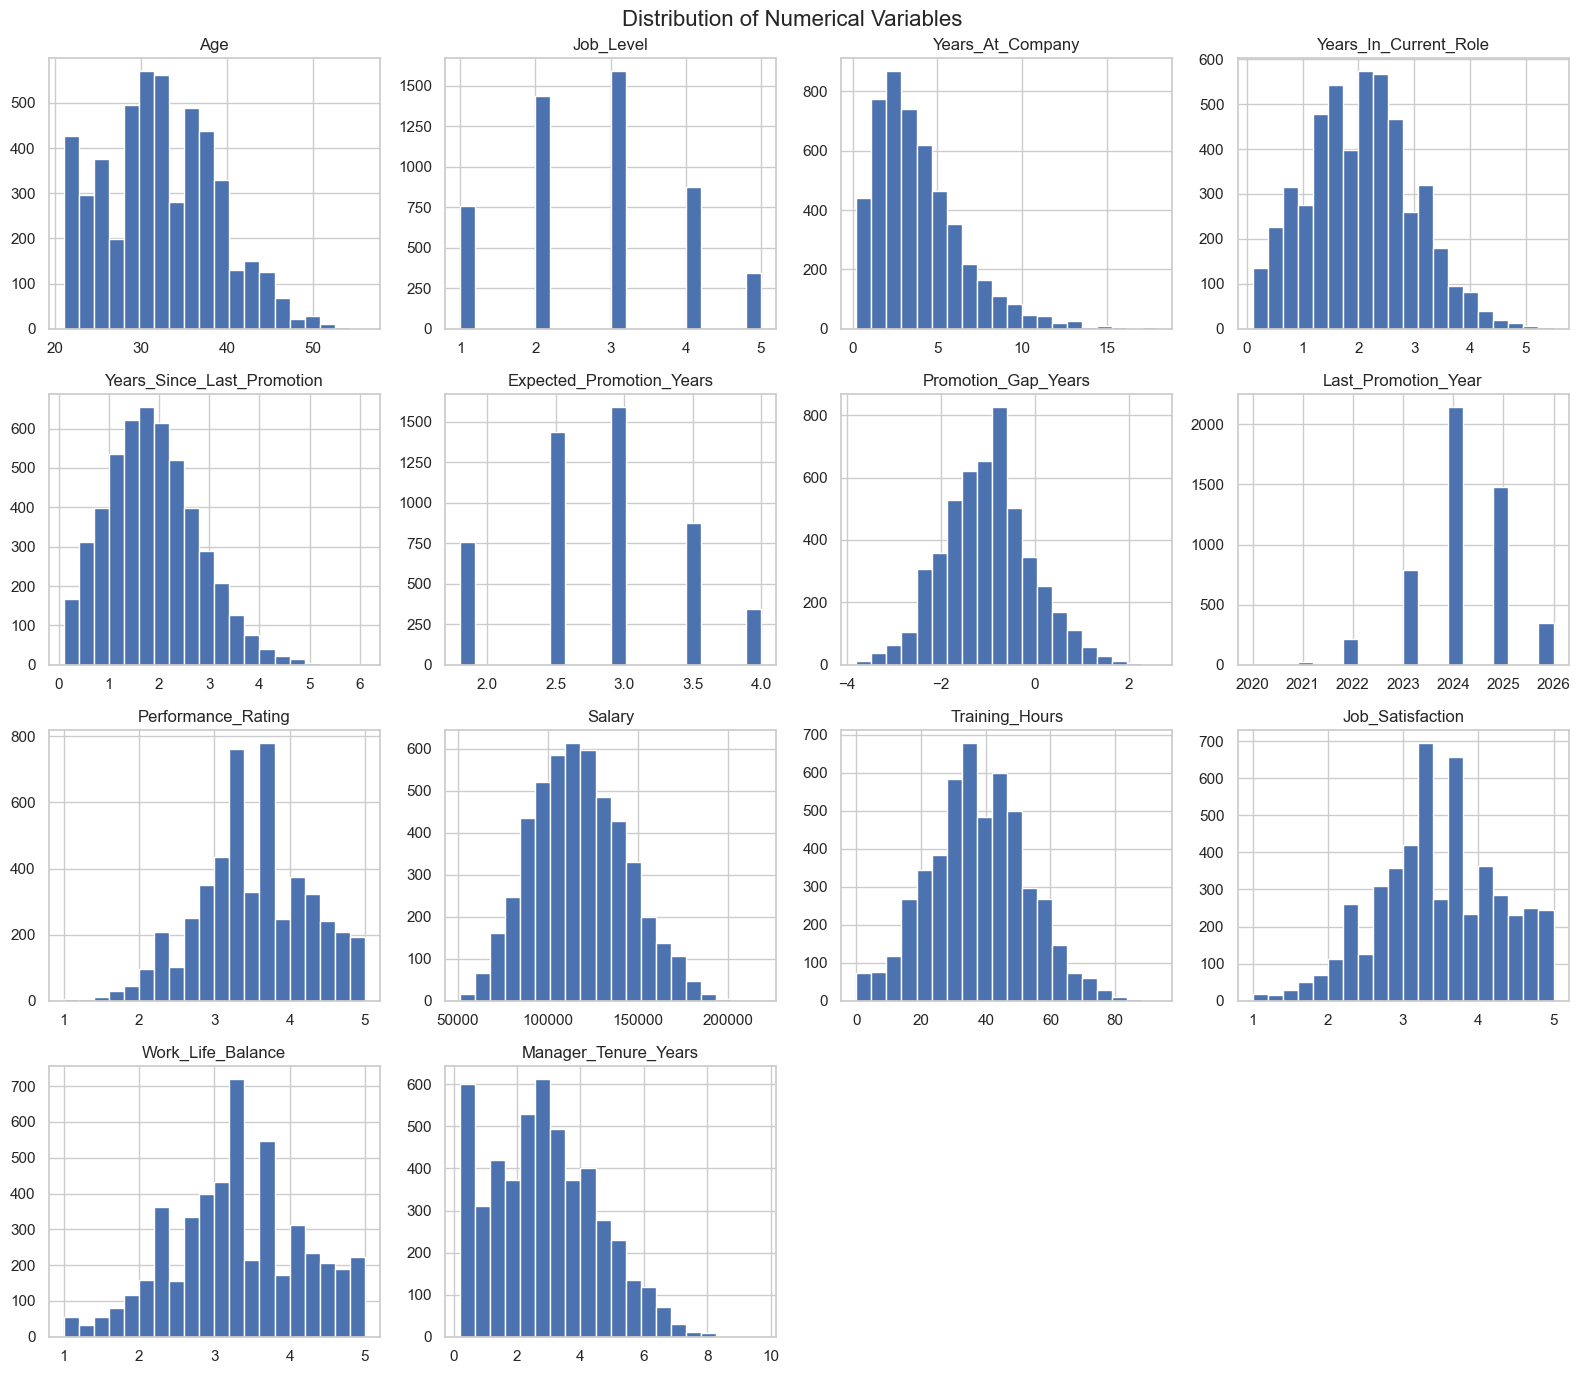

In [12]:
df[numeric_cols].hist(figsize=(16, 14), bins=20)

plt.suptitle("Distribution of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

### Boxplot Analysis

Boxplots help identify the median, spread, and potential extreme
observations in numerical variables.

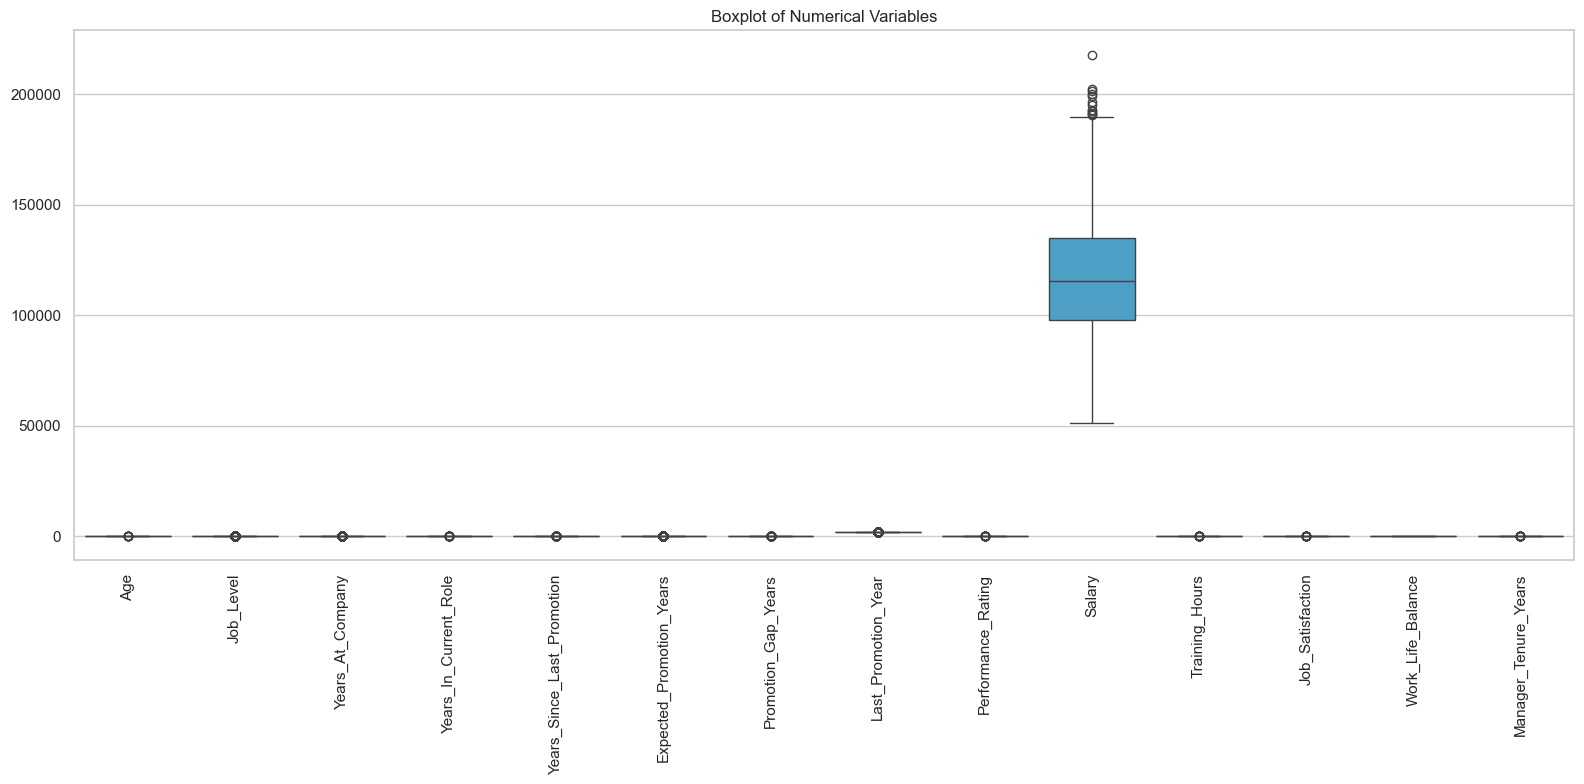

In [13]:
plt.figure(figsize=(16, 8))

sns.boxplot(data=df[numeric_cols])

plt.title("Boxplot of Numerical Variables")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 4. Employee Distribution by Department

This analysis shows how employees are distributed across departments.

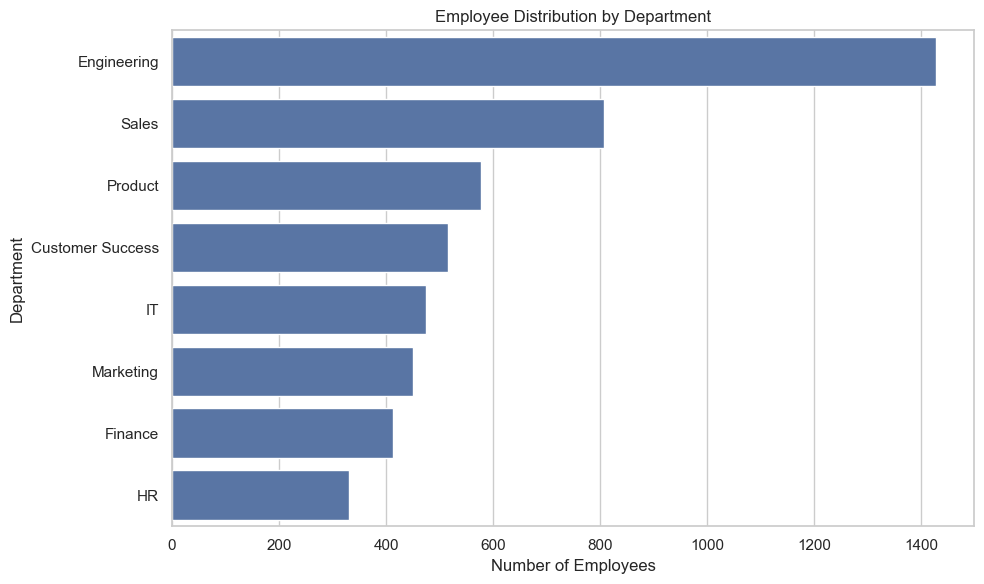

Largest Department: Engineering
Employees: 1428
Smallest Department: HR
Employees: 331


In [14]:
department_counts = df["Department"].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=department_counts.values,
    y=department_counts.index
)

plt.title("Employee Distribution by Department")
plt.xlabel("Number of Employees")
plt.ylabel("Department")
plt.tight_layout()
plt.show()

print("Largest Department:", department_counts.idxmax())
print("Employees:", department_counts.max())
print("Smallest Department:", department_counts.idxmin())
print("Employees:", department_counts.min())

## 5. Employee Distribution by Job Role

This analysis identifies the most and least common job roles in
the dataset.

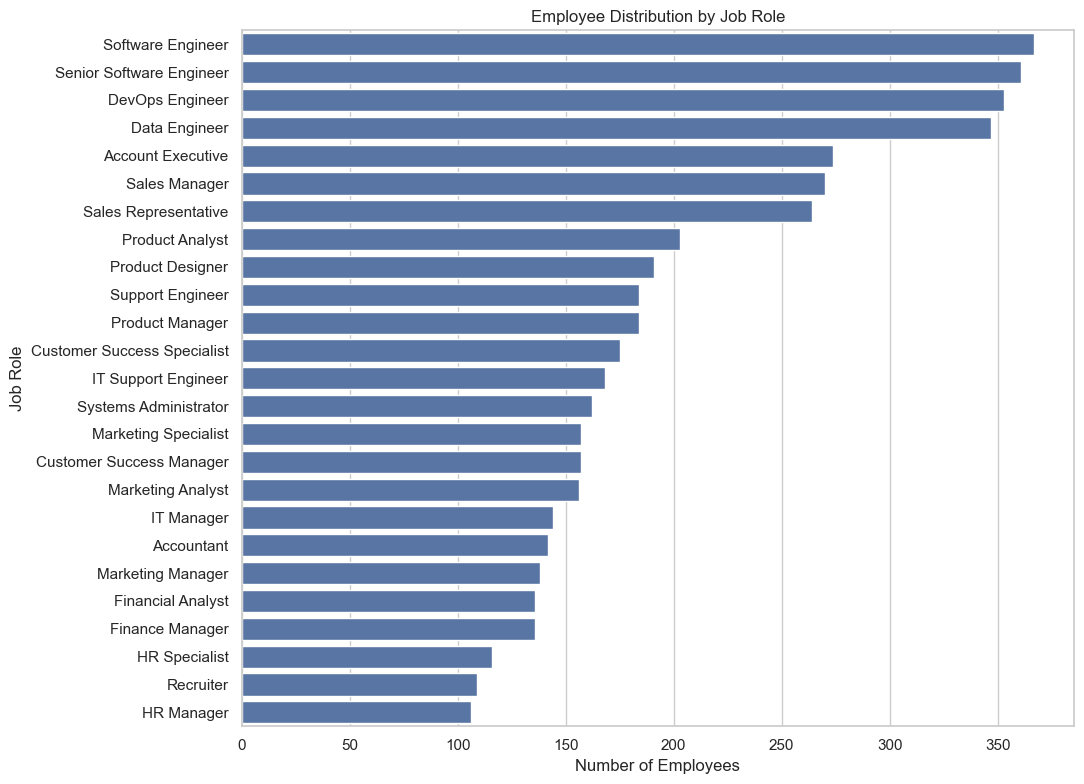

Most Common Job Role: Software Engineer
Employees: 367


In [15]:
role_counts = df["Job_Role"].value_counts()

plt.figure(figsize=(11, 8))

sns.barplot(
    x=role_counts.values,
    y=role_counts.index
)

plt.title("Employee Distribution by Job Role")
plt.xlabel("Number of Employees")
plt.ylabel("Job Role")
plt.tight_layout()
plt.show()

print("Most Common Job Role:", role_counts.idxmax())
print("Employees:", role_counts.max())

## 6. Employee Distribution by Job Level

Job level represents the hierarchical level of employees.

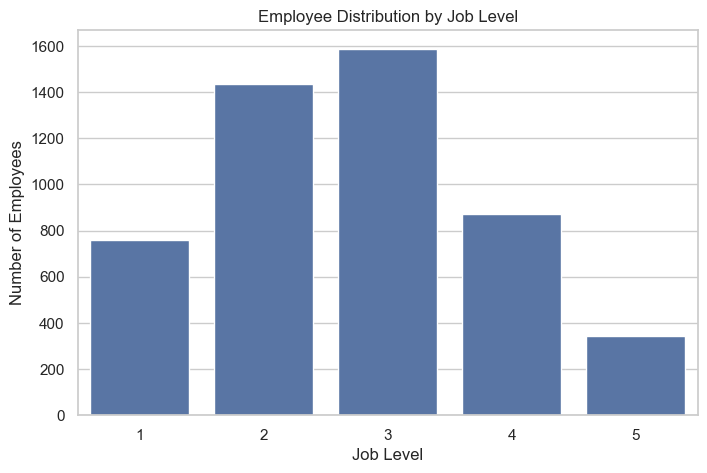

In [16]:
level_counts = df["Job_Level"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=level_counts.index,
    y=level_counts.values
)

plt.title("Employee Distribution by Job Level")
plt.xlabel("Job Level")
plt.ylabel("Number of Employees")
plt.show()

# Bivariate Analysis

Bivariate analysis examines relationships between two variables.

The analysis below focuses on relationships that provide meaningful
employee and HR insights.

## 7. Salary vs Job Level

### Business Question

Does salary increase across different job levels?

In [17]:
salary_level = df.groupby("Job_Level")["Salary"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

salary_level

,count,mean,median,min,max
Job_Level,,,,,
1,760,85213.68,85400.0,51200,133300
2,1435,103604.60,102800.0,65800,161900
3,1589,122803.46,122300.0,75200,173000
4,872,141550.69,141300.0,91200,195100
5,344,157996.80,158650.0,116300,218100


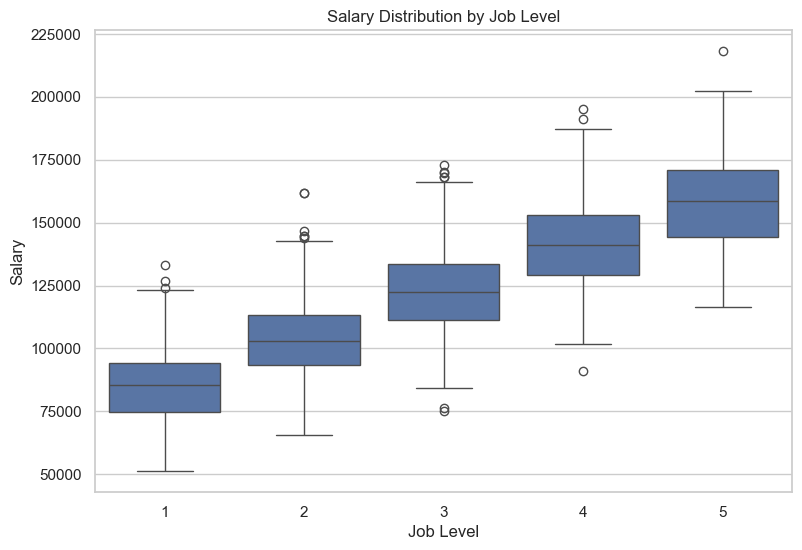

In [18]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Job_Level",
    y="Salary"
)

plt.title("Salary Distribution by Job Level")
plt.xlabel("Job Level")
plt.ylabel("Salary")
plt.show()

## 8. Salary vs Years at Company

### Business Question

Is there an observable relationship between company experience
and salary?

In [19]:
salary_experience_corr = df["Years_At_Company"].corr(df["Salary"])

print(
    f"Correlation between Years at Company and Salary: "
    f"{salary_experience_corr:.2f}"
)

Correlation between Years at Company and Salary: 0.23


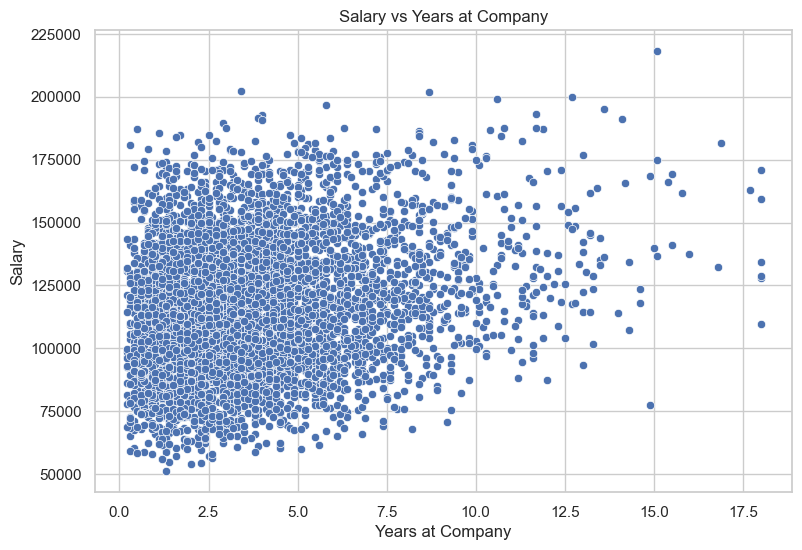

In [20]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Years_At_Company",
    y="Salary"
)

plt.title("Salary vs Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Salary")
plt.show()

## 9. Salary by Department

### Business Question

How does salary distribution differ across departments?

In [21]:
department_salary = (
    df.groupby("Department")["Salary"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
    .round(2)
)

department_salary

,count,mean,median
Department,,,
Engineering,1428,130905.46,130300.0
Product,578,126688.58,126600.0
IT,474,116455.06,115000.0
Sales,808,114381.56,113450.0
Finance,414,106190.58,105500.0
Marketing,451,106123.28,106400.0
Customer Success,516,103162.98,102800.0
HR,331,101260.42,100400.0


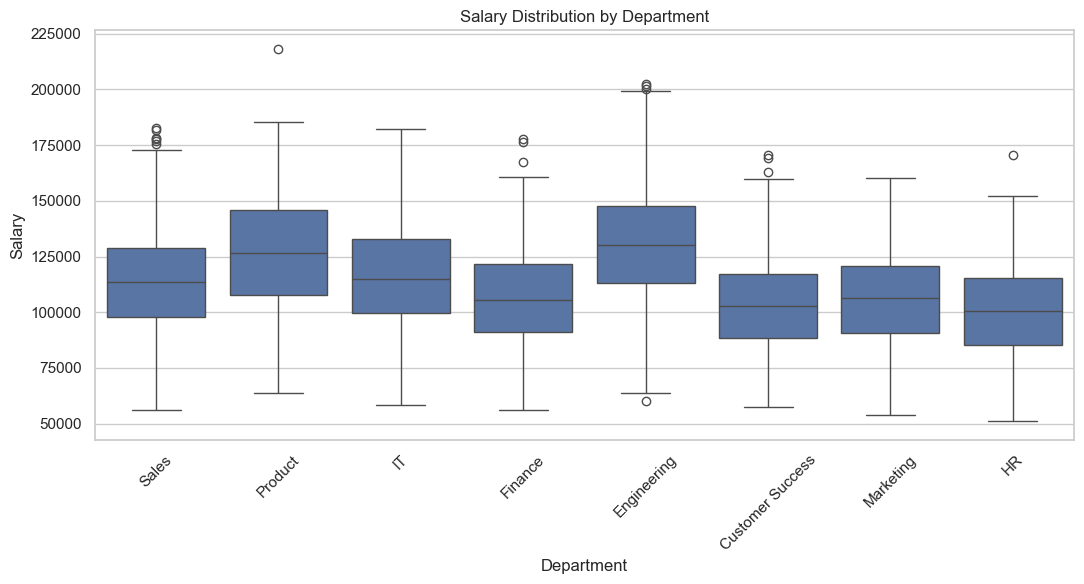

In [22]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df,
    x="Department",
    y="Salary"
)

plt.title("Salary Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Salary")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Performance and Promotion

### Business Question

Do promoted employees have different performance ratings
compared with non-promoted employees?

In [23]:
performance_promotion = (
    df.groupby("Promotion_Status")["Performance_Rating"]
    .agg(["count", "mean", "median"])
    .round(2)
)

performance_promotion

,count,mean,median
Promotion_Status,,,
Not Promoted,2716,3.28,3.3
Promoted,2284,3.77,3.8


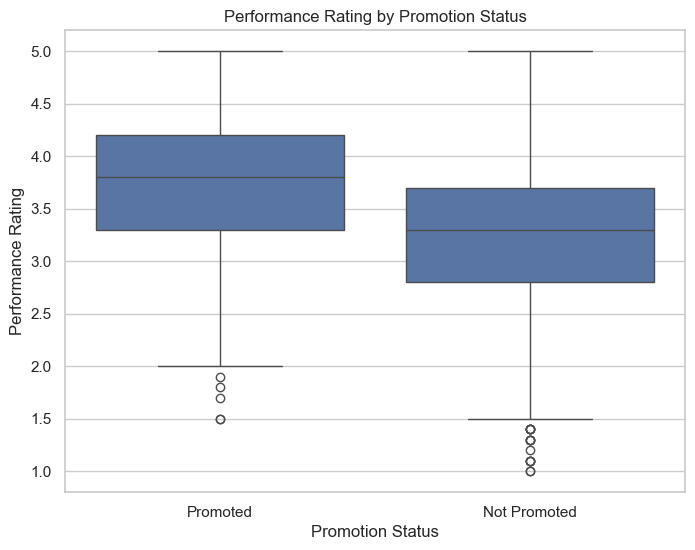

In [24]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Promotion_Status",
    y="Performance_Rating"
)

plt.title("Performance Rating by Promotion Status")
plt.xlabel("Promotion Status")
plt.ylabel("Performance Rating")
plt.show()

## 11. Promotion Rate by Department

### Business Question

Does the promotion rate vary across departments?

Percentages are used instead of raw counts so that departments
can be compared fairly.

In [25]:
promotion_by_dept = pd.crosstab(
    df["Department"],
    df["Promotion_Status"],
    normalize="index"
).mul(100).round(2)

promotion_by_dept

Promotion_Status,Not Promoted,Promoted
Department,,
Customer Success,52.52,47.48
Engineering,53.85,46.15
Finance,53.38,46.62
HR,52.87,47.13
IT,55.91,44.09
Marketing,54.10,45.90
Product,54.15,45.85
Sales,56.68,43.32


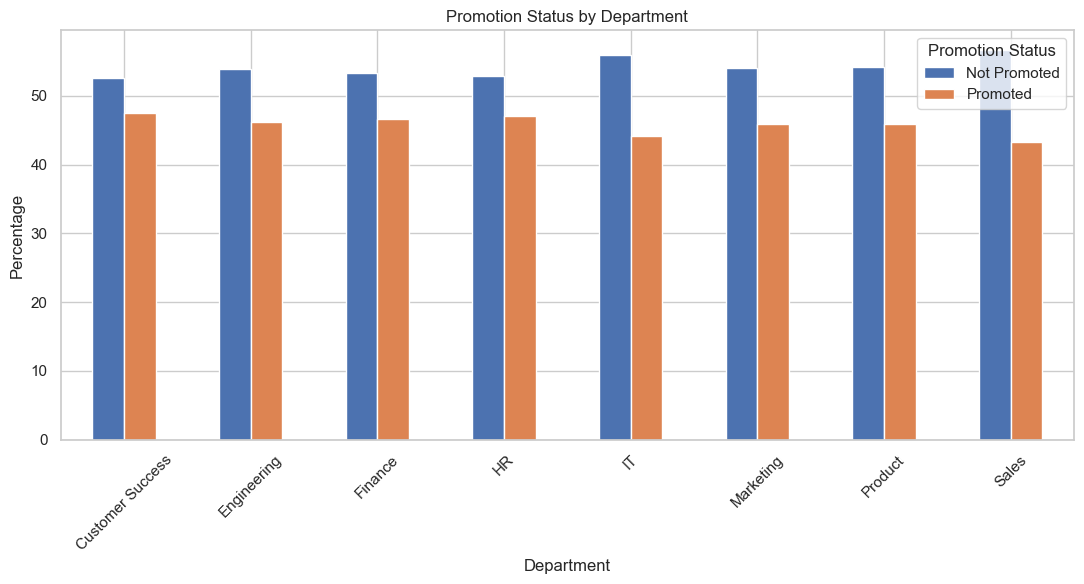

In [26]:
promotion_by_dept.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Promotion Status by Department")
plt.xlabel("Department")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(title="Promotion Status")
plt.tight_layout()
plt.show()

## 12. Job Satisfaction and Attrition

### Business Question

Does job satisfaction differ between employees who stayed
and employees who left?

In [27]:
satisfaction_attrition = (
    df.groupby("Attrition")["Job_Satisfaction"]
    .agg(["count", "mean", "median"])
    .round(2)
)

satisfaction_attrition

,count,mean,median
Attrition,,,
No,4564,3.48,3.5
Yes,436,3.19,3.2


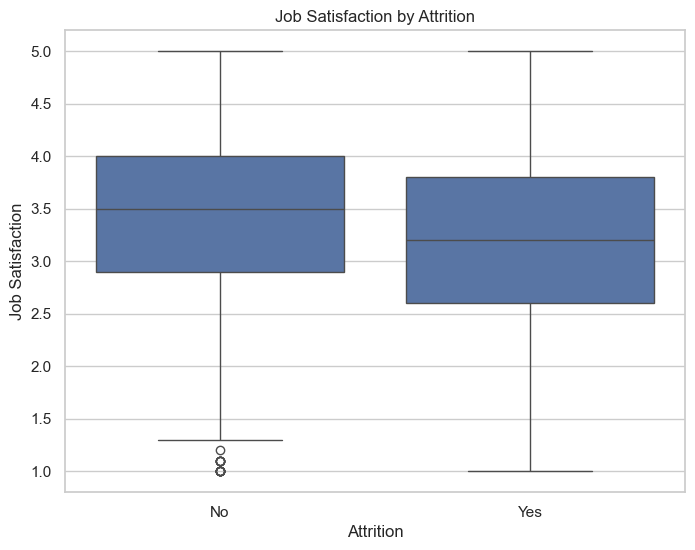

In [28]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Attrition",
    y="Job_Satisfaction"
)

plt.title("Job Satisfaction by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Job Satisfaction")
plt.show()

## 13. Overtime and Attrition

### Business Question

Is attrition different between employees who work overtime
and those who do not?

In [29]:
overtime_attrition = pd.crosstab(
    df["Overtime"],
    df["Attrition"],
    normalize="index"
).mul(100).round(2)

overtime_attrition

Attrition,No,Yes
Overtime,,
No,92.28,7.72
Yes,88.24,11.76


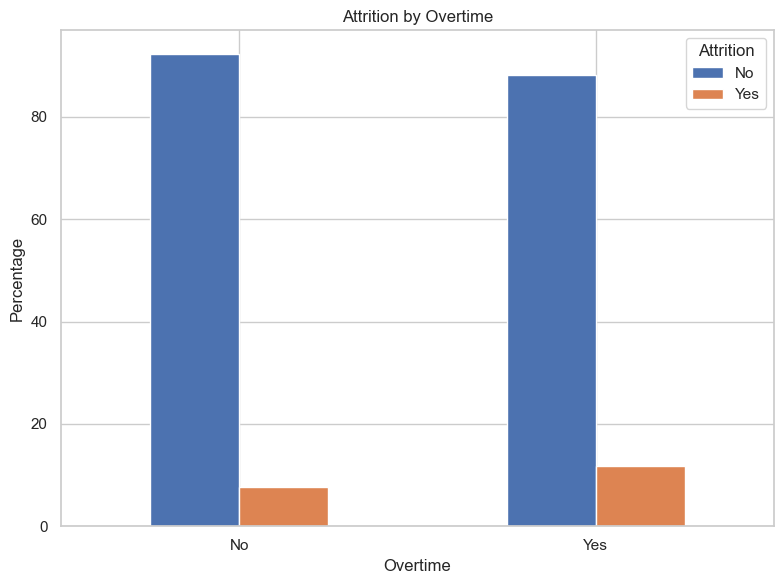

In [30]:
overtime_attrition.plot(
    kind="bar",
    figsize=(8, 6)
)

plt.title("Attrition by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

## 14. Remote Work and Attrition

### Business Question

Does attrition vary between remote and non-remote employees?

In [31]:
remote_attrition = pd.crosstab(
    df["Remote_Work"],
    df["Attrition"],
    normalize="index"
).mul(100).round(2)

remote_attrition

Attrition,No,Yes
Remote_Work,,
No,91.54,8.46
Yes,90.92,9.08


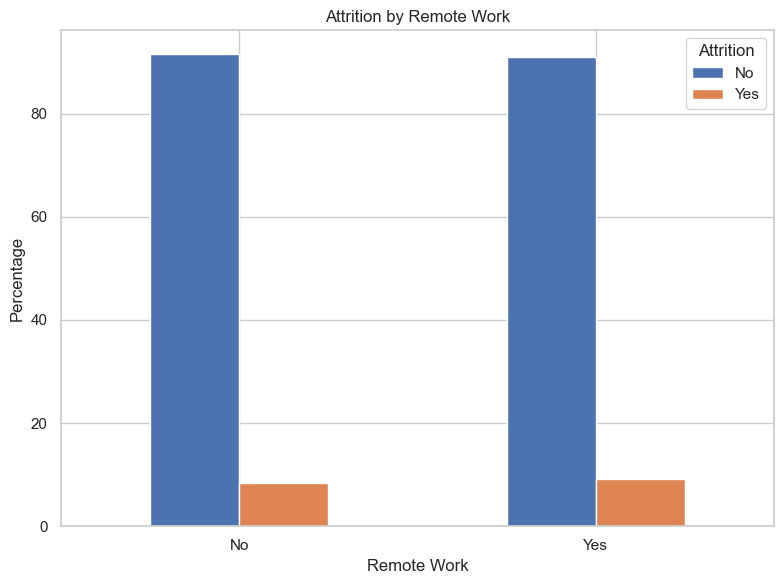

In [32]:
remote_attrition.plot(
    kind="bar",
    figsize=(8, 6)
)

plt.title("Attrition by Remote Work")
plt.xlabel("Remote Work")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

## 15. Work-Life Balance and Attrition

### Business Question

Does work-life balance differ between employees who stayed
and employees who left?

In [33]:
worklife_attrition = (
    df.groupby("Attrition")["Work_Life_Balance"]
    .agg(["count", "mean", "median"])
    .round(2)
)

worklife_attrition

,count,mean,median
Attrition,,,
No,4564,3.30,3.3
Yes,436,3.12,3.2


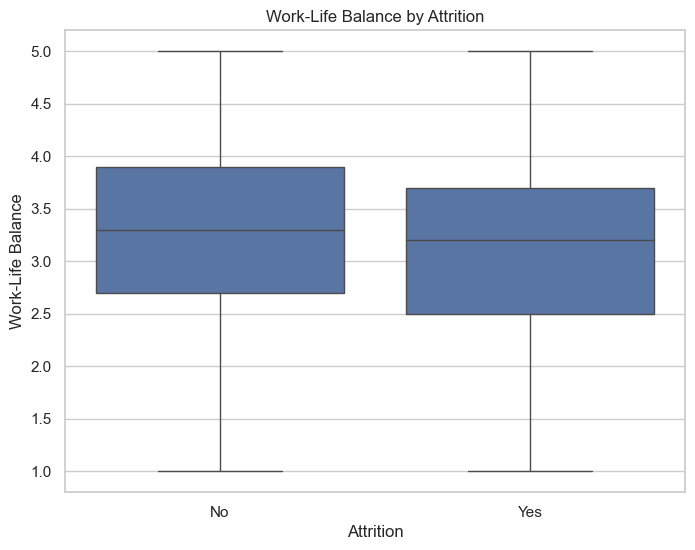

In [34]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Attrition",
    y="Work_Life_Balance"
)

plt.title("Work-Life Balance by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Work-Life Balance")
plt.show()

## 16. Salary and Attrition

### Business Question

Does salary distribution differ between employees who stayed
and employees who left?

In [35]:
salary_attrition = (
    df.groupby("Attrition")["Salary"]
    .agg(["count", "mean", "median"])
    .round(2)
)

salary_attrition

,count,mean,median
Attrition,,,
No,4564,117316.98,115600.0
Yes,436,116784.63,115200.0


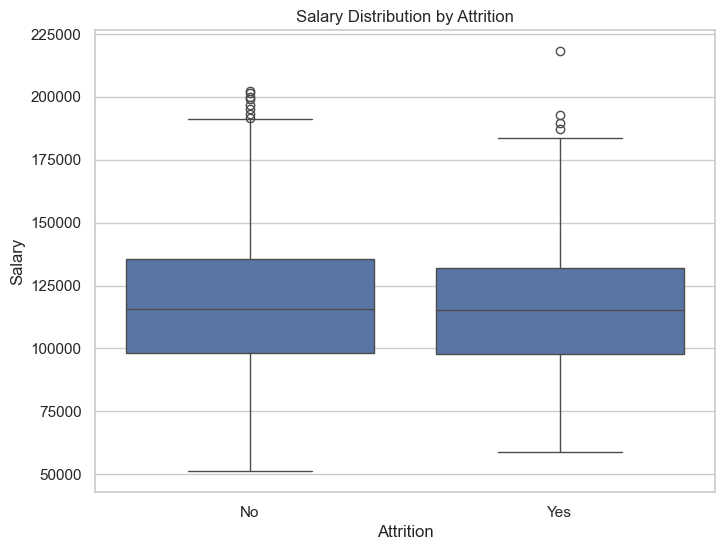

In [36]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Attrition",
    y="Salary"
)

plt.title("Salary Distribution by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Salary")
plt.show()

## 17. Age and Attrition

### Business Question

Does employee age differ between employees who stayed
and employees who left?

In [37]:
age_attrition = (
    df.groupby("Attrition")["Age"]
    .agg(["count", "mean", "median"])
    .round(2)
)

age_attrition

,count,mean,median
Attrition,,,
No,4564,32.13,32.0
Yes,436,32.38,32.0


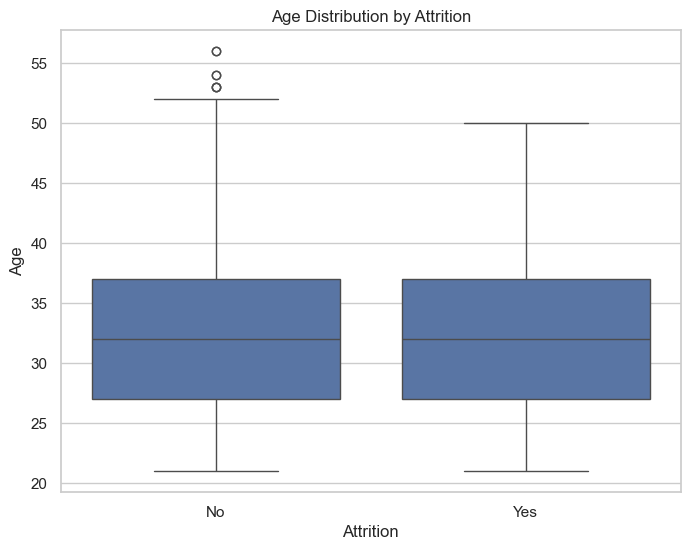

In [38]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Attrition",
    y="Age"
)

plt.title("Age Distribution by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Age")
plt.show()

## 18. Performance and Attrition

### Business Question

Does performance rating differ between employees who stayed
and employees who left?

In [39]:
performance_attrition = (
    df.groupby("Attrition")["Performance_Rating"]
    .agg(["count", "mean", "median"])
    .round(2)
)

performance_attrition

,count,mean,median
Attrition,,,
No,4564,3.51,3.5
Yes,436,3.40,3.4


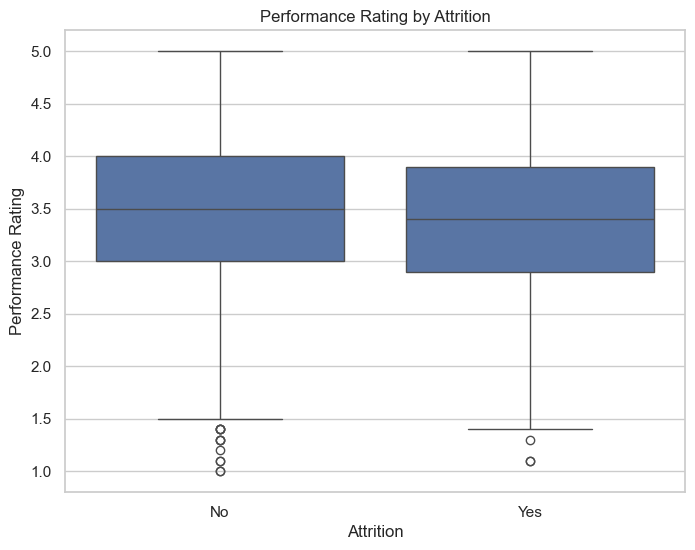

In [40]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Attrition",
    y="Performance_Rating"
)

plt.title("Performance Rating by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Performance Rating")
plt.show()

## 19. Department and Attrition

### Business Question

Does attrition rate vary across departments?

We use percentages because department sizes may differ.

In [41]:
department_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
).mul(100).round(2)

department_attrition

Attrition,No,Yes
Department,,
Customer Success,91.47,8.53
Engineering,90.62,9.38
Finance,91.79,8.21
HR,91.54,8.46
IT,91.98,8.02
Marketing,92.68,7.32
Product,90.83,9.17
Sales,91.09,8.91


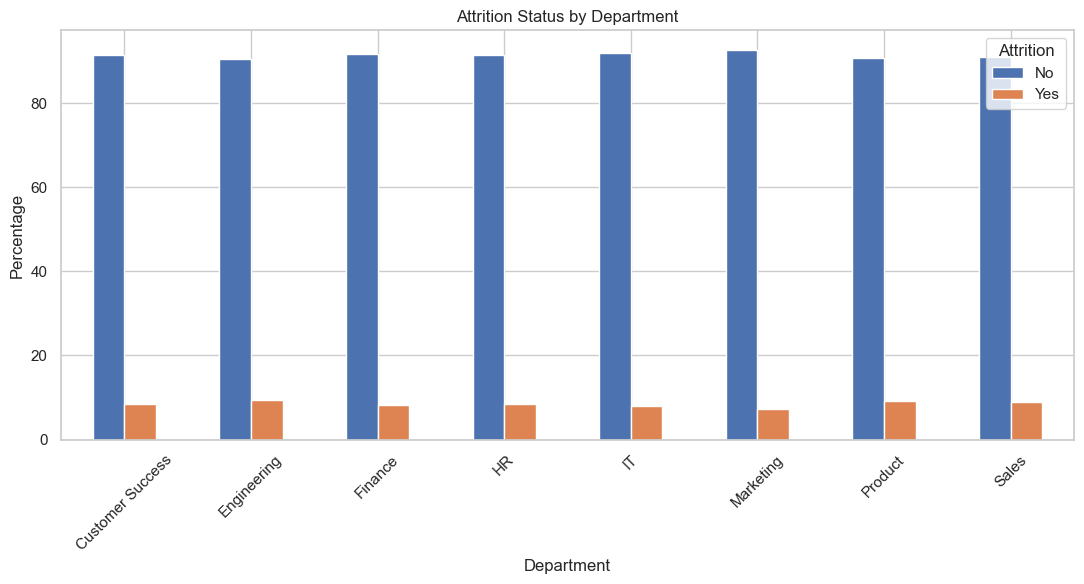

In [42]:
department_attrition.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Attrition Status by Department")
plt.xlabel("Department")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

## 20. Promotion Gap and Promotion Status

### Business Question

Does the promotion gap differ between promoted and
non-promoted employees?

In [43]:
promotion_gap = (
    df.groupby("Promotion_Status")["Promotion_Gap_Years"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

promotion_gap

,count,mean,median,min,max
Promotion_Status,,,,,
Not Promoted,2716,-1.09,-1.2,-3.8,2.6
Promoted,2284,-0.91,-0.9,-3.2,2.2


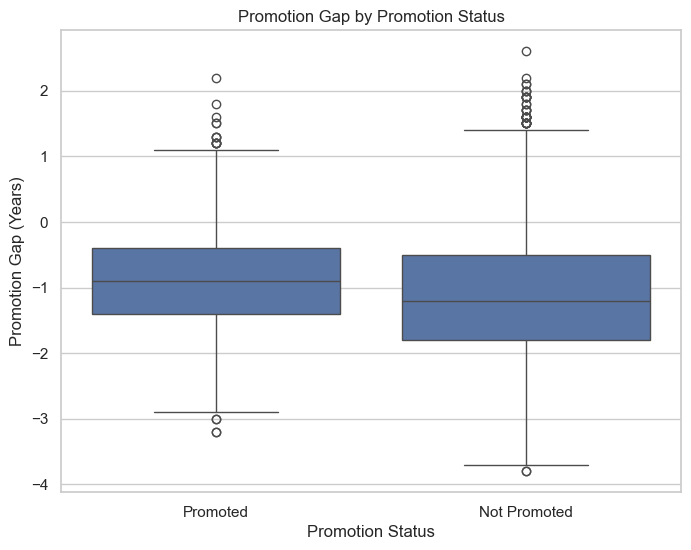

In [44]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Promotion_Status",
    y="Promotion_Gap_Years"
)

plt.title("Promotion Gap by Promotion Status")
plt.xlabel("Promotion Status")
plt.ylabel("Promotion Gap (Years)")
plt.show()

## 21. Company Experience and Promotion

### Business Question

Does company experience differ between promoted and
non-promoted employees?

In [45]:
experience_promotion = (
    df.groupby("Promotion_Status")["Years_At_Company"]
    .agg(["count", "mean", "median"])
    .round(2)
)

experience_promotion

,count,mean,median
Promotion_Status,,,
Not Promoted,2716,3.34,2.7
Promoted,2284,4.60,3.9


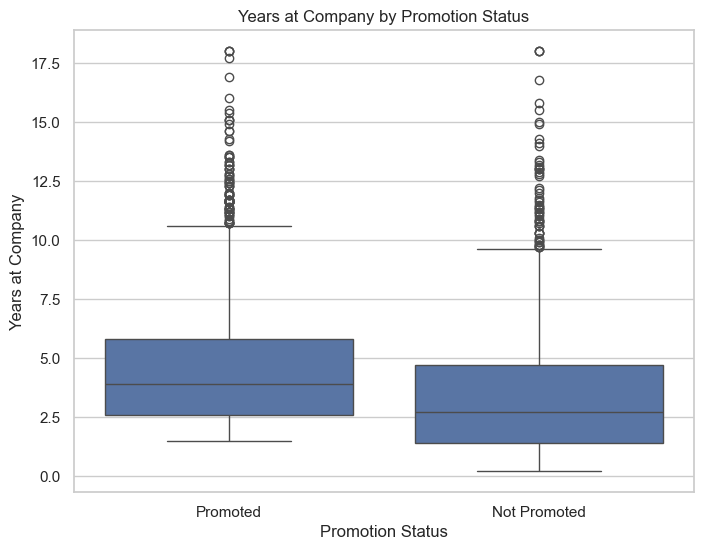

In [46]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Promotion_Status",
    y="Years_At_Company"
)

plt.title("Years at Company by Promotion Status")
plt.xlabel("Promotion Status")
plt.ylabel("Years at Company")
plt.show()

## 22. Training Hours and Performance

### Business Question

Is there an observable relationship between training hours
and performance rating?

In [47]:
training_performance_corr = df["Training_Hours"].corr(
    df["Performance_Rating"]
)

print(
    f"Correlation between Training Hours and Performance Rating: "
    f"{training_performance_corr:.2f}"
)

Correlation between Training Hours and Performance Rating: 0.23


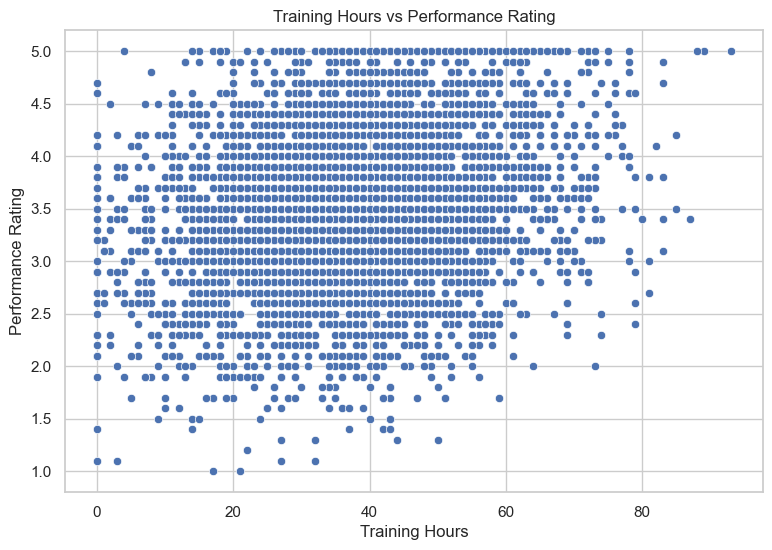

In [48]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Training_Hours",
    y="Performance_Rating"
)

plt.title("Training Hours vs Performance Rating")
plt.xlabel("Training Hours")
plt.ylabel("Performance Rating")
plt.show()

## 23. Training Hours and Promotion

### Business Question

Do promoted and non-promoted employees differ in training hours?

In [49]:
training_promotion = (
    df.groupby("Promotion_Status")["Training_Hours"]
    .agg(["count", "mean", "median"])
    .round(2)
)

training_promotion

,count,mean,median
Promotion_Status,,,
Not Promoted,2716,36.73,36.0
Promoted,2284,38.63,38.0


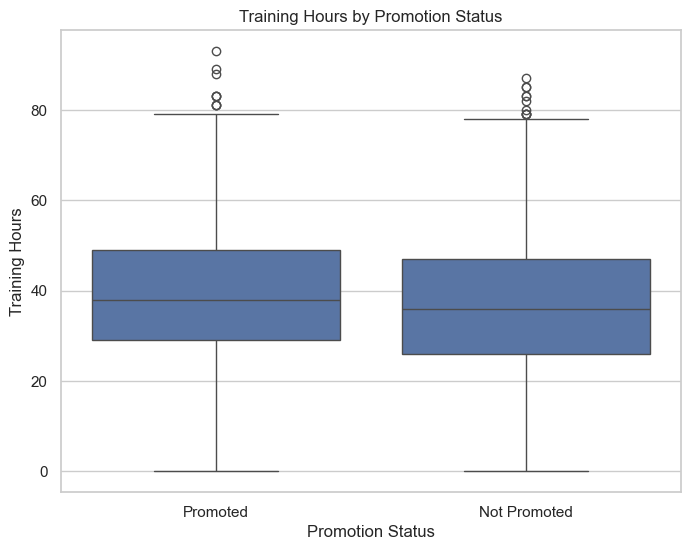

In [50]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Promotion_Status",
    y="Training_Hours"
)

plt.title("Training Hours by Promotion Status")
plt.xlabel("Promotion Status")
plt.ylabel("Training Hours")
plt.show()

## 24. Job Satisfaction and Promotion

### Business Question

Does job satisfaction differ between promoted and
non-promoted employees?

In [51]:
satisfaction_promotion = (
    df.groupby("Promotion_Status")["Job_Satisfaction"]
    .agg(["count", "mean", "median"])
    .round(2)
)

satisfaction_promotion

,count,mean,median
Promotion_Status,,,
Not Promoted,2716,3.38,3.4
Promoted,2284,3.53,3.5


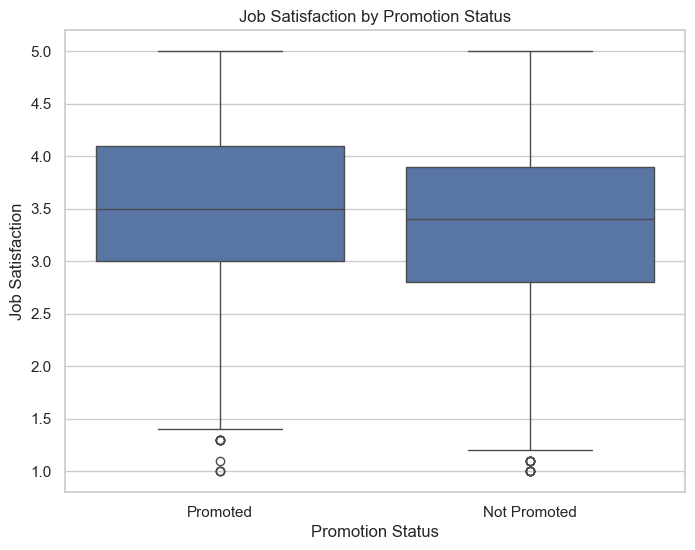

In [52]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Promotion_Status",
    y="Job_Satisfaction"
)

plt.title("Job Satisfaction by Promotion Status")
plt.xlabel("Promotion Status")
plt.ylabel("Job Satisfaction")
plt.show()

# Advanced EDA

## Correlation Analysis

Correlation is used to understand the strength and direction
of linear relationships between numerical variables.

Correlation does not imply causation.

In [53]:
correlation = df[numeric_cols].corr()
correlation.round(2)

,Age,Job_Level,Years_At_Company,Years_In_Current_Role,Years_Since_Last_Promotion,Expected_Promotion_Years,Promotion_Gap_Years,Last_Promotion_Year,Performance_Rating,Salary,Training_Hours,Job_Satisfaction,Work_Life_Balance,Manager_Tenure_Years
Age,1.00,0.04,-0.02,-0.01,-0.01,0.04,-0.03,0.01,0.01,0.02,0.02,-0.00,-0.00,-0.02
Job_Level,0.04,1.00,-0.01,0.32,0.30,1.00,-0.37,-0.29,-0.00,0.80,-0.03,0.03,-0.00,-0.00
Years_At_Company,-0.02,-0.01,1.00,0.41,0.40,-0.01,0.39,-0.39,0.00,0.23,0.01,-0.03,-0.00,-0.01
Years_In_Current_Role,-0.01,0.32,0.41,1.00,0.94,0.32,0.71,-0.90,-0.00,0.35,0.01,-0.03,0.01,0.00
Years_Since_Last_Promotion,-0.01,0.30,0.40,0.94,1.00,0.30,0.78,-0.95,-0.01,0.33,0.02,-0.04,0.01,0.00
Expected_Promotion_Years,0.04,1.00,-0.01,0.32,0.30,1.00,-0.37,-0.29,-0.00,0.80,-0.03,0.03,-0.00,-0.00
Promotion_Gap_Years,-0.03,-0.37,0.39,0.71,0.78,-0.37,1.00,-0.74,-0.00,-0.20,0.04,-0.06,0.01,0.00
Last_Promotion_Year,0.01,-0.29,-0.39,-0.90,-0.95,-0.29,-0.74,1.00,0.01,-0.32,-0.01,0.05,-0.01,0.00
Performance_Rating,0.01,-0.00,0.00,-0.00,-0.01,-0.00,-0.00,0.01,1.00,0.09,0.23,0.30,-0.00,-0.00
Salary,0.02,0.80,0.23,0.35,0.33,0.80,-0.20,-0.32,0.09,1.00,0.00,0.04,-0.00,-0.01


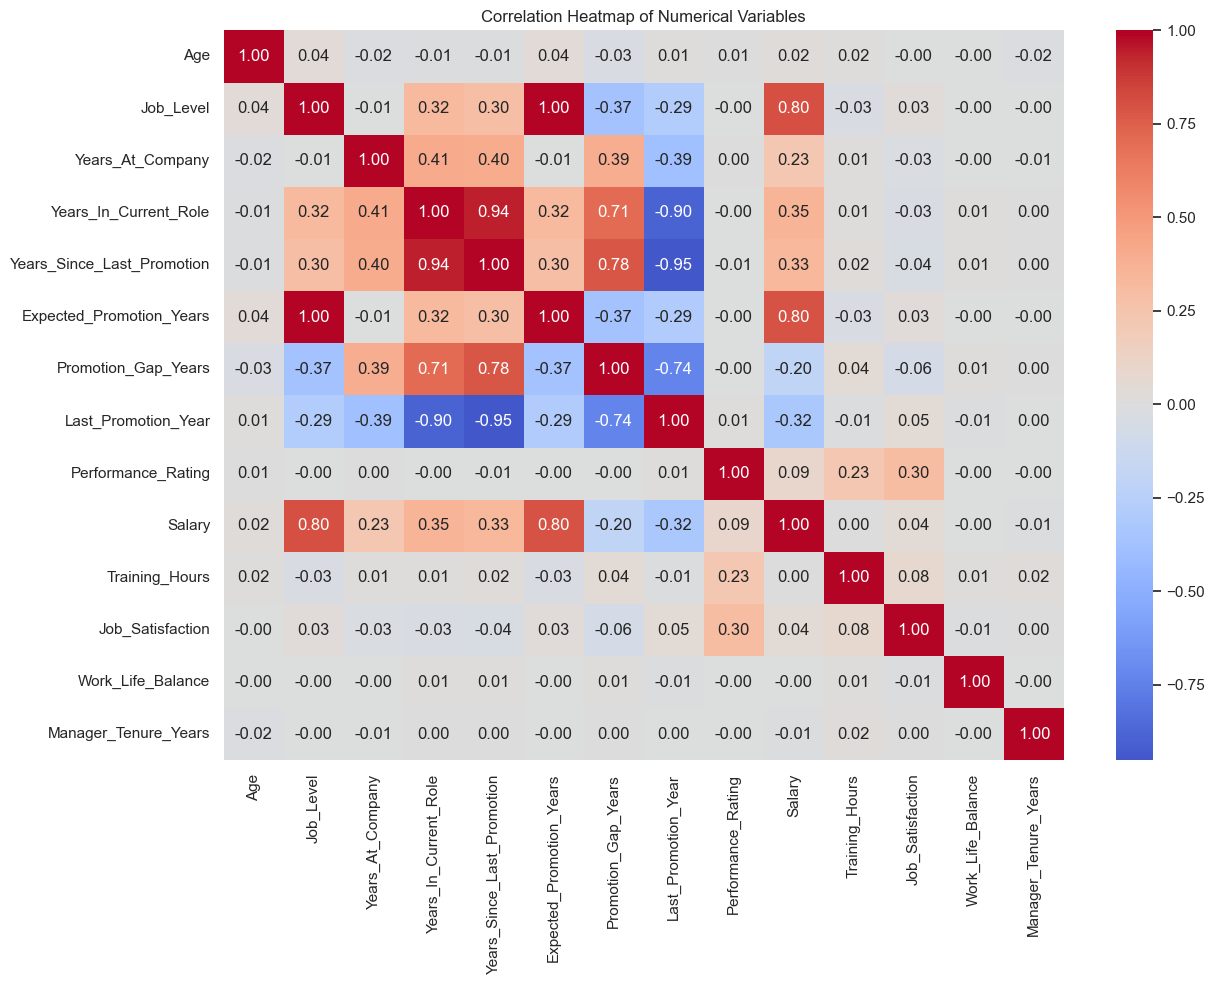

In [54]:
plt.figure(figsize=(13, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

## 25. Strongest Numerical Relationships

We identify the strongest correlations automatically instead of
manually inspecting every value in the correlation matrix.

In [55]:
corr_pairs = (
    correlation
    .where(np.triu(np.ones(correlation.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda x: abs(x), ascending=False)
)

corr_pairs.head(10).round(3)

Job_Level                   Expected_Promotion_Years      0.996
Years_Since_Last_Promotion  Last_Promotion_Year          -0.952
Years_In_Current_Role       Years_Since_Last_Promotion    0.939
                            Last_Promotion_Year          -0.897
Job_Level                   Salary                        0.802
Expected_Promotion_Years    Salary                        0.799
Years_Since_Last_Promotion  Promotion_Gap_Years           0.779
Promotion_Gap_Years         Last_Promotion_Year          -0.738
Years_In_Current_Role       Promotion_Gap_Years           0.707
Years_At_Company            Years_In_Current_Role         0.406
dtype: float64

## 26. Age Group Analysis

Employees are grouped into age ranges to examine whether
attrition patterns differ across age groups.

In [56]:
age_group = pd.cut(
    df["Age"],
    bins=[0, 25, 35, 45, np.inf],
    labels=["<=25", "26-35", "36-45", "46+"]
)

age_attrition = pd.crosstab(
    age_group,
    df["Attrition"],
    normalize="index"
).mul(100).round(2)

age_attrition

Attrition,No,Yes
Age,,
<=25,91.00,9.00
26-35,91.81,8.19
36-45,91.23,8.77
46+,83.58,16.42


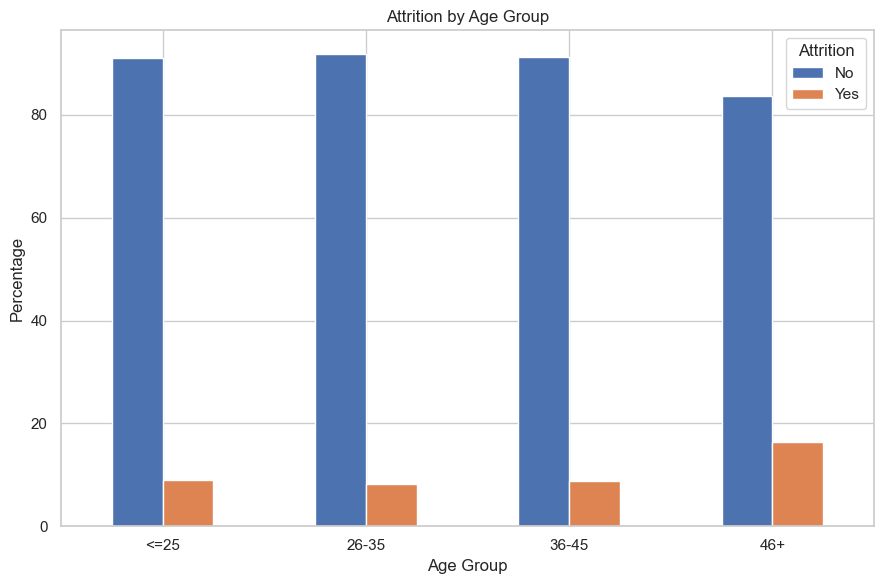

In [57]:
age_attrition.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Attrition by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

## 27. Job Level and Promotion

### Business Question

Does promotion status vary across different job levels?

In [58]:
joblevel_promotion = pd.crosstab(
    df["Job_Level"],
    df["Promotion_Status"],
    normalize="index"
).mul(100).round(2)

joblevel_promotion

Promotion_Status,Not Promoted,Promoted
Job_Level,,
1,57.37,42.63
2,55.05,44.95
3,53.81,46.19
4,49.89,50.11
5,58.14,41.86


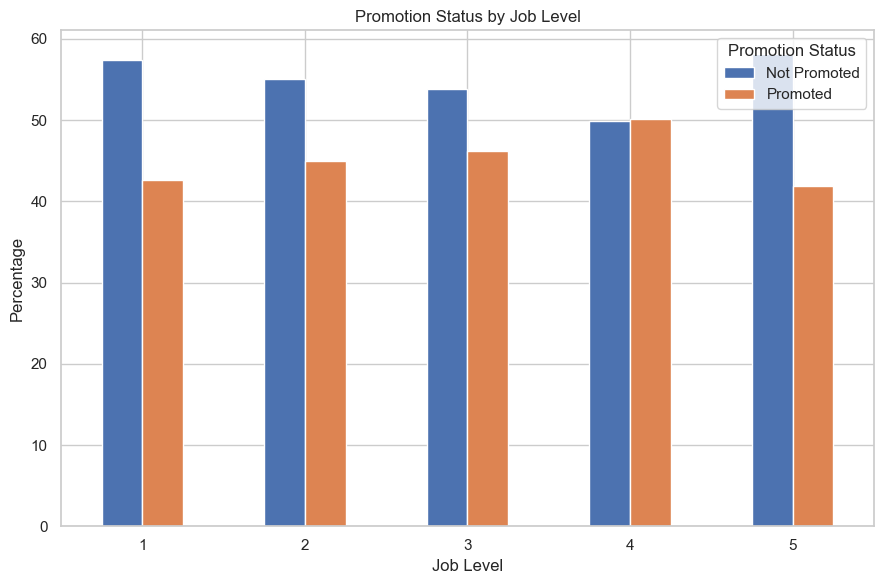

In [59]:
joblevel_promotion.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Promotion Status by Job Level")
plt.xlabel("Job Level")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Promotion Status")
plt.tight_layout()
plt.show()

# Key Business Metrics

This section summarizes important overall metrics from the dataset.

In [60]:
total_employees = len(df)

promoted = (df["Promotion_Status"] == "Promoted").sum()
attrition = (df["Attrition"] == "Yes").sum()

promotion_rate = promoted / total_employees * 100
attrition_rate = attrition / total_employees * 100

print(f"Total Employees       : {total_employees:,}")
print(f"Promoted Employees    : {promoted:,}")
print(f"Promotion Rate        : {promotion_rate:.2f}%")
print(f"Employees with Attrition: {attrition:,}")
print(f"Attrition Rate        : {attrition_rate:.2f}%")

Total Employees       : 5,000
Promoted Employees    : 2,284
Promotion Rate        : 45.68%
Employees with Attrition: 436
Attrition Rate        : 8.72%


In [61]:
print("Average Age:", round(df["Age"].mean(), 2))
print("Average Salary:", round(df["Salary"].mean(), 2))
print("Average Company Experience:", round(df["Years_At_Company"].mean(), 2))
print("Average Performance Rating:", round(df["Performance_Rating"].mean(), 2))
print("Average Training Hours:", round(df["Training_Hours"].mean(), 2))
print("Average Job Satisfaction:", round(df["Job_Satisfaction"].mean(), 2))

Average Age: 32.15
Average Salary: 117270.56
Average Company Experience: 3.91
Average Performance Rating: 3.5
Average Training Hours: 37.6
Average Job Satisfaction: 3.45


# Automated Key Findings

The following section automatically identifies important
patterns from the analysis.

In [62]:
print("KEY FINDINGS")
print("=" * 40)

print("Largest department:", df["Department"].value_counts().idxmax())

print("Most common job role:", df["Job_Role"].value_counts().idxmax())

print("Highest salary department:", department_salary["mean"].idxmax())

print("Highest salary job level:", salary_level["mean"].idxmax())

print("Promotion rate:", round(promotion_rate, 2), "%")

print("Attrition rate:", round(attrition_rate, 2), "%")

print(
    "Strongest correlation:",
    corr_pairs.index[0][0],
    "and",
    corr_pairs.index[0][1],
    round(corr_pairs.iloc[0], 2)
)

KEY FINDINGS
Largest department: Engineering
Most common job role: Software Engineer
Highest salary department: Engineering
Highest salary job level: 5
Promotion rate: 45.68 %
Attrition rate: 8.72 %
Strongest correlation: Job_Level and Expected_Promotion_Years 1.0


# EDA Conclusion

The Exploratory Data Analysis provided a comprehensive understanding
of the employee dataset.

The analysis covered:

- Employee demographics
- Department and job-role distribution
- Job levels
- Salary and experience
- Performance
- Training
- Job satisfaction
- Work-life balance
- Promotion
- Attrition
- Correlation between numerical variables

Different visualization techniques were used, including:

- Histograms
- Boxplots
- Bar charts
- Count plots
- Scatter plots
- Percentage-based comparison charts
- Correlation heatmaps

The analysis also examined important HR questions related to
promotion and employee attrition.

The identified relationships and patterns can be used as a
foundation for further statistical analysis, predictive modeling,
and machine learning.

# Final Summary

## EDA Workflow

The analysis followed the complete EDA process:

1. Loaded the cleaned dataset.
2. Examined dataset structure and statistics.
3. Identified numerical and categorical variables.
4. Performed univariate analysis.
5. Visualized numerical distributions.
6. Analyzed categorical distributions.
7. Performed bivariate analysis.
8. Investigated salary and experience.
9. Investigated performance and promotion.
10. Investigated satisfaction and attrition.
11. Investigated overtime and remote work.
12. Investigated department-level promotion and attrition.
13. Analyzed promotion gap.
14. Analyzed training and performance.
15. Performed correlation analysis.
16. Performed age-group segmentation.
17. Analyzed job level and promotion.
18. Generated overall business metrics.
19. Generated automated key findings.

## Final Conclusion

The cleaned employee dataset contains useful information for
understanding workforce characteristics, compensation,
performance, promotion, employee satisfaction, and attrition.

The EDA establishes the major patterns and relationships in the
dataset and provides a strong foundation for further analysis.